In [28]:
import pandas as pd  
import matplotlib.pyplot as plt 

# ==========================================
#  טעינת הנתונים 
# ==========================================


df = pd.read_csv('england_all_cleaned.csv')


df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA,Unnamed: 132
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40458,E3,02/05/2026,Harrogate,Barnet,1.0,2.0,A,1.0,1.0,D,...,2.80,3.7,2.30,NaN,NaN,NaN,2.70,3.60,2.40,NaN
40459,E3,02/05/2026,Notts County,Bristol Rvs,1.0,1.0,D,1.0,0.0,H,...,1.70,3.9,4.50,NaN,NaN,NaN,1.67,4.00,4.50,NaN
40460,E3,02/05/2026,Oldham,Accrington,3.0,0.0,H,1.0,0.0,H,...,1.85,3.7,3.90,NaN,NaN,NaN,1.91,3.75,3.70,NaN
40461,E3,02/05/2026,Swindon,Chesterfield,1.0,2.0,A,1.0,1.0,D,...,3.30,3.6,2.05,NaN,NaN,NaN,3.30,3.70,2.05,NaN


In [29]:
# הצגת שמות העמודות 
df.columns

Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG',
       'HTAG', 'HTR',
       ...
       'BVCH', 'BVCD', 'BVCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA',
       'Unnamed: 132'],
      dtype='object', length=192)

In [30]:
#רשימת העמודות החשובות 
keep_cols = [ 
    'Date', 'HomeTeam', 'AwayTeam',
    'FTHG',                    # שערי בית עד סוף המשחק
    'FTAG',                    # שערי חוץ עד סוף המשחק
    'FTR',                     # תוצאה סופית (H/D/A)
    'HTHG', 'HTAG', 'HTR',     # מחצית
    'HS', 'AS',                # בעיטות
    'HST', 'AST',              # בעיטות למסגרת
    'HF', 'AF',                # עבירות
    'HC', 'AC',                # קרנות
    'HY', 'AY',                # צהובים
    'HR', 'AR',            # אדומים
]


# עכשיו מסננים רק את העמודות האלה
df = df[keep_cols]   

# מוחקים את כל השורות הריקות
df=df.dropna() 

In [31]:
df.shape

(40453, 21)

In [32]:
df.describe

<bound method NDFrame.describe of              Date      HomeTeam      AwayTeam  FTHG  FTAG FTR  HTHG  HTAG HTR  \
0        19/08/06       Arsenal   Aston Villa   1.0   1.0   D   0.0   0.0   D   
1        19/08/06        Bolton     Tottenham   2.0   0.0   H   2.0   0.0   H   
2        19/08/06       Everton       Watford   2.0   1.0   H   1.0   0.0   H   
3        19/08/06     Newcastle         Wigan   2.0   1.0   H   1.0   0.0   H   
4        19/08/06    Portsmouth     Blackburn   3.0   0.0   H   1.0   0.0   H   
...           ...           ...           ...   ...   ...  ..   ...   ...  ..   
40458  02/05/2026     Harrogate        Barnet   1.0   2.0   A   1.0   1.0   D   
40459  02/05/2026  Notts County   Bristol Rvs   1.0   1.0   D   1.0   0.0   H   
40460  02/05/2026        Oldham    Accrington   3.0   0.0   H   1.0   0.0   H   
40461  02/05/2026       Swindon  Chesterfield   1.0   2.0   A   1.0   1.0   D   
40462  02/05/2026      Tranmere       Grimsby   1.0   1.0   D   0.0   1.0  

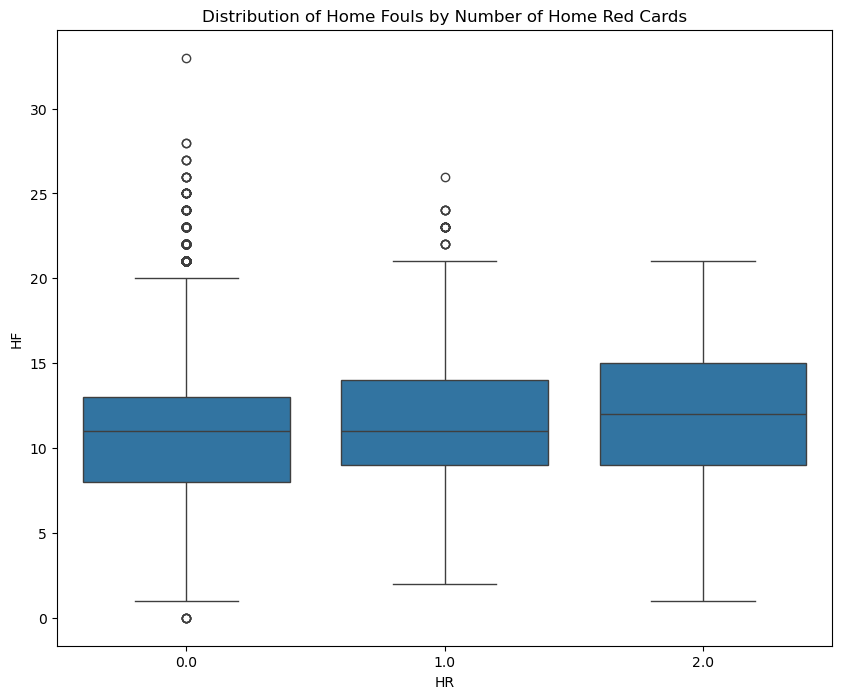

In [21]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='HR', y='HF')
ax.set_title("Distribution of Home Fouls by Number of Home Red Cards")
plt.show()

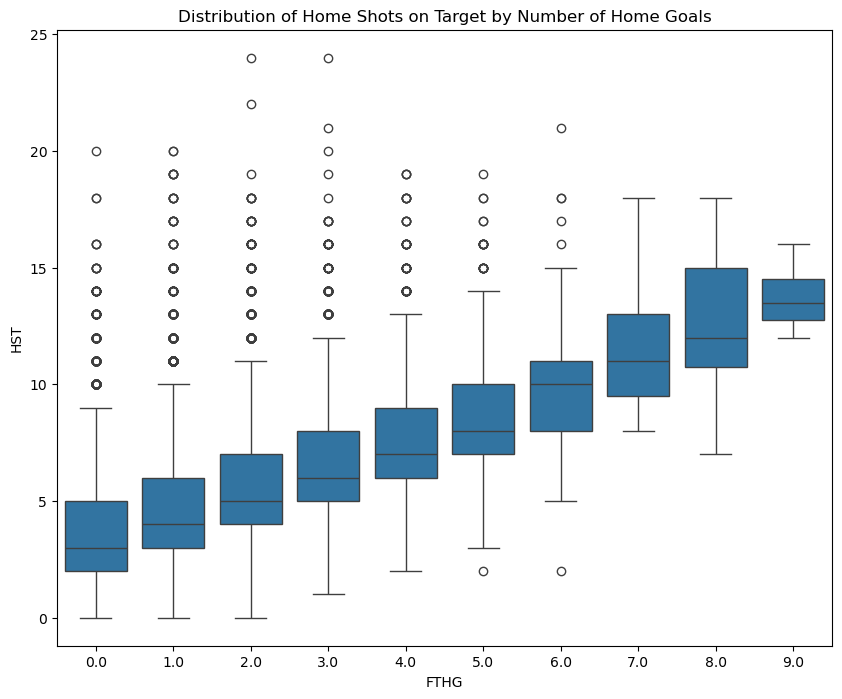

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='FTHG', y='HST')
ax.set_title('Distribution of Home Shots on Target by Number of Home Goals')
plt.show()

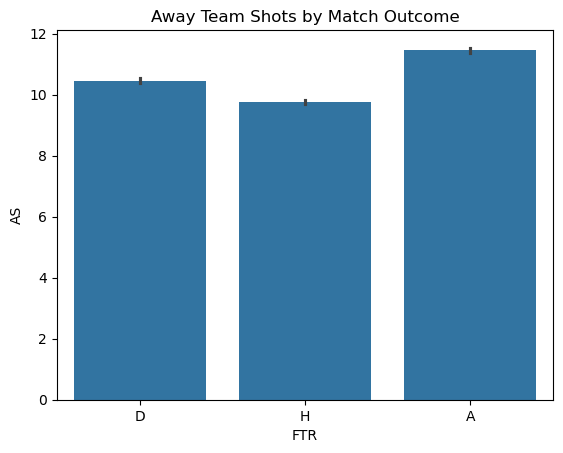

In [10]:
sns.barplot(data=df, x='FTR', y='AS')
plt.title("Away Team Shots by Match Outcome")
plt.show()

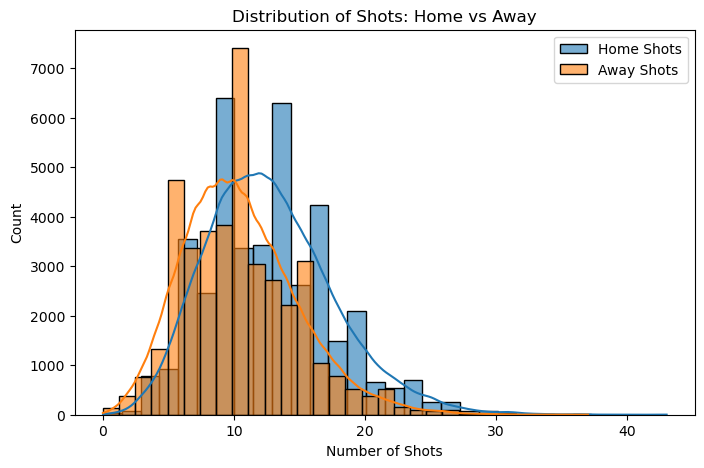

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['HS'], bins=30, kde=True, label='Home Shots', alpha=0.6)
sns.histplot(df['AS'], bins=30, kde=True, label='Away Shots', alpha=0.6)
plt.title('Distribution of Shots: Home vs Away')
plt.xlabel('Number of Shots')
plt.ylabel('Count')
plt.legend()
plt.show()

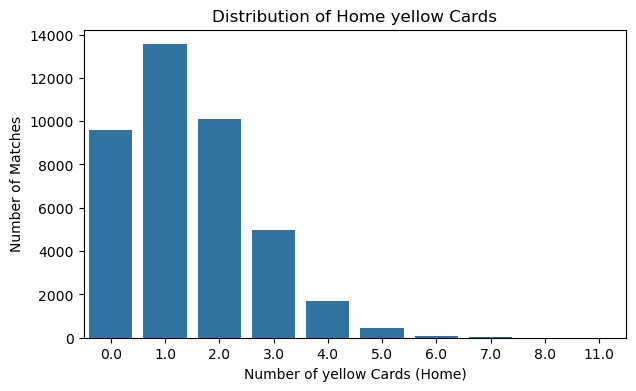

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(x='HY', data=df)
plt.title('Distribution of Home yellow Cards')
plt.xlabel('Number of yellow Cards (Home)')
plt.ylabel('Number of Matches')
plt.show()

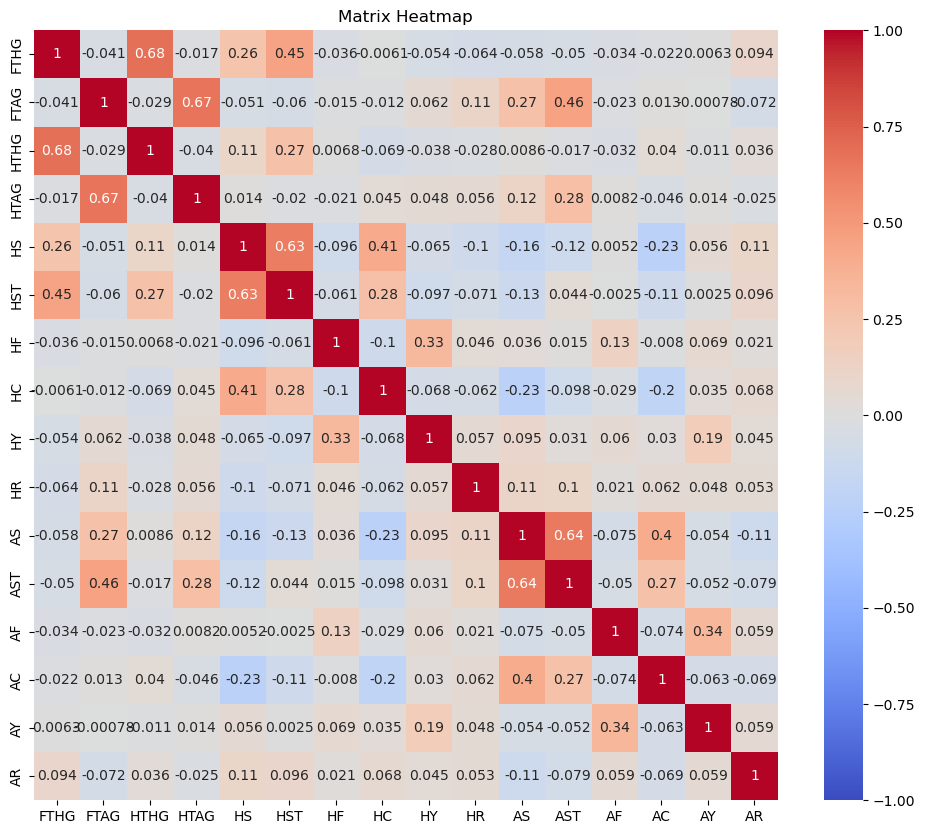

In [13]:
plt.figure(figsize=(12,10))
corr = df[['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS','HST','HF','HC','HY','HR','AS','AST','AF','AC','AY','AR']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrix Heatmap')
plt.show()

In [33]:
from sklearn.model_selection import train_test_split

#====== יצירת משתנה המטרה והנדסת פ'צרים למשימת סיווג ===========

# משתנה המטרה הוא לחזות האם הקבוצה הביתית תנצח או לא (ערכים של 0 או 1)
df['home_win'] = (df['FTHG'] > df['FTAG']).astype(int) 

# הסרת עמודות שאינן מספריות או כאלו שכוללות את תוצאת המשחק כדי למנוע הטיה בחיזוי
df = df.drop(columns=['Date','HomeTeam', 'AwayTeam','HTR','FTR','FTHG','FTAG']) 

X = df.drop('home_win', axis=1)
y = df['home_win']

# חלוקה ל-Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

מתחיל באימון המודלים...
 Random Forest סיים אימון. דיוק: 76.83%


C:\Users\2023\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:29:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost סיים אימון. דיוק: 77.37%
 LightGBM סיים אימון. דיוק: 77.26%


C:\Users\2023\AppData\Local\Temp\ipykernel_23616\978955206.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")


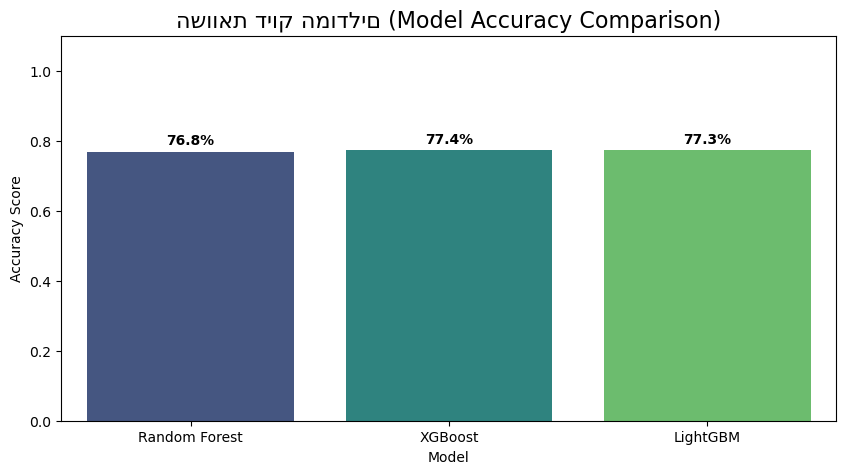

C:\Users\2023\AppData\Local\Temp\ipykernel_23616\978955206.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, ax=axes[i], palette='magma')
C:\Users\2023\AppData\Local\Temp\ipykernel_23616\978955206.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, ax=axes[i], palette='magma')
C:\Users\2023\AppData\Local\Temp\ipykernel_23616\978955206.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, ax=axes[i], palette='

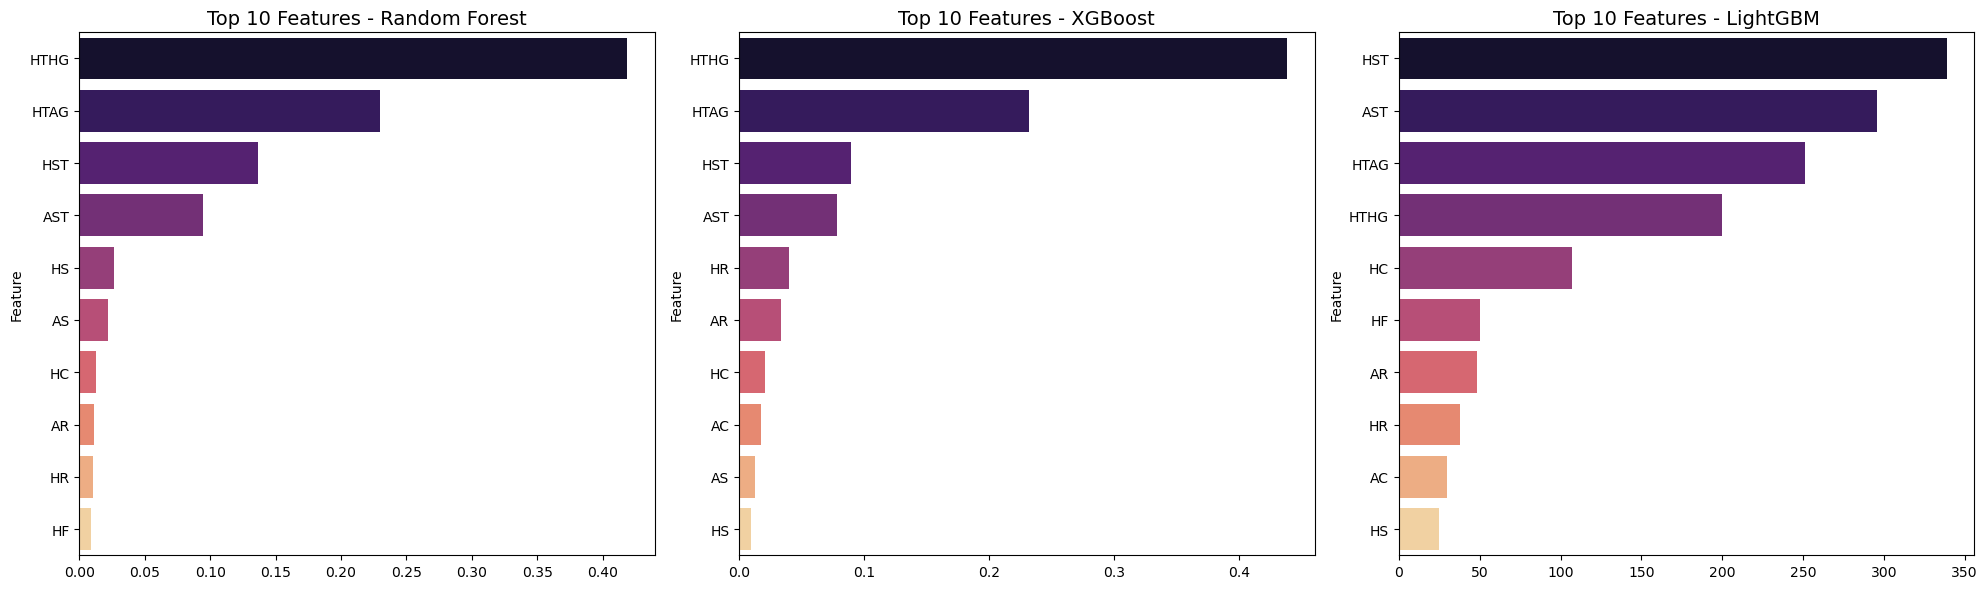


 דוח תחזיות משחקים (מבוסס על המודל הטוב ביותר: XGBoost)
מציג 10 משחקים אקראיים מקבוצת הבדיקה:
--------------------------------------------------------------------------------
         HS    AS  HST  AST    HF    AF   HC   AC   HY   AY   HR   AR  Actual_Result  Predicted_Result  Prob_No_Home_Win (%)  Prob_Home_Win (%)
10012   6.0  14.0  4.0  5.0   9.0   8.0  4.0  2.0  1.0  0.0  0.0  0.0              1                 0             67.809998          32.189999
16912  14.0   9.0  3.0  2.0  12.0  20.0  5.0  2.0  2.0  4.0  0.0  0.0              0                 0             89.629997          10.370000
37103  17.0   8.0  7.0  2.0  12.0   9.0  7.0  1.0  2.0  5.0  0.0  0.0              1                 1             11.610000          88.389999
12513  15.0  10.0  9.0  5.0  13.0  18.0  4.0  3.0  1.0  3.0  0.0  0.0              1                 1             21.820000          78.180000
3928   14.0   9.0  6.0  8.0  10.0   5.0  4.0  2.0  2.0  1.0  0.0  0.0              0                 0  

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ייבוא המודלים
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

from sklearn.metrics import accuracy_score, roc_auc_score


# ==========================================
#  אימון המודלים
# ==========================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=100, max_depth=4, learning_rate=0.05),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, verbose=-1)
}

results = []
trained_models = {}

print("מתחיל באימון המודלים...")

for name, model in models.items():
    # אימון
    model.fit(X_train, y_train)
    trained_models[name] = model

    # חיזוי (קלאס והסתברות)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # ההסתברות ל-1 (שבירה)

    # שמירת מדדים
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({"Model": name, "Accuracy": acc, "AUC": auc})
    print(f" {name} סיים אימון. דיוק: {acc:.2%}")

# ==========================================
# השוואה ויזואלית בין המודלים (Bar Chart)
# ==========================================
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")
plt.ylim(0, 1.1) # כדי שיהיה רווח למעלה
plt.title("השוואת דיוק המודלים (Model Accuracy Comparison)", fontsize=16)
plt.ylabel("Accuracy Score")
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 0.02, f'{row.Accuracy:.1%}', color='black', ha="center", fontweight='bold')
plt.show()

# ==========================================
# הצגת Top 10 Features לכל מודל בנפרד
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # 3 גרפים בשורה אחת

for i, (name, model) in enumerate(trained_models.items()):
    # חילוץ חשיבות הפיצ'רים
    importances = model.feature_importances_
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)

    # ציור הגרף
    sns.barplot(x='Importance', y='Feature', data=feat_imp, ax=axes[i], palette='magma')
    axes[i].set_title(f'Top 10 Features - {name}', fontsize=14)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


# ==========================================
# דוח תחזיות למשחקים (הסתברות לניצחון ביתי מול אי-ניצחון)
# ==========================================
# בחירת המודל הטוב ביותר לפי מדד הדיוק
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]

# חישוב הסתברויות החיזוי על קבוצת הבדיקה
# predict_proba מחזיר: [הסתברות ל-0 (לא ניצחון), הסתברות ל-1 (ניצחון ביתי)]
probs = best_model.predict_proba(X_test)

# יצירת DataFrame להצגת התחזיות
prediction_report = X_test.copy()
prediction_report['Actual_Result'] = y_test                 # התוצאה האמיתית
prediction_report['Predicted_Result'] = best_model.predict(X_test)  # החיזוי של המודל

# === הוספת הסתברויות החיזוי (באחוזים) ===
prediction_report['Prob_No_Home_Win (%)'] = (probs[:, 0] * 100).round(2)   # אי-ניצחון ביתי
prediction_report['Prob_Home_Win (%)'] = (probs[:, 1] * 100).round(2)      # ניצחון ביתי

# בחירת עמודות רלוונטיות להצגה
display_cols = [
    'HS', 'AS',           # בעיטות
    'HST', 'AST',         # בעיטות למסגרת
    'HF', 'AF',           # עבירות
    'HC', 'AC',           # קרנות
    'HY', 'AY',           # כרטיסים צהובים
    'HR', 'AR',           # כרטיסים אדומים
    'Actual_Result',
    'Predicted_Result',
    'Prob_No_Home_Win (%)',
    'Prob_Home_Win (%)'
]

print(f"\n דוח תחזיות משחקים (מבוסס על המודל הטוב ביותר: {best_model_name})")
print("מציג 10 משחקים אקראיים מקבוצת הבדיקה:")
print("-" * 80)

# הצגת 10 משחקים אקראיים
print(prediction_report[display_cols].sample(10).to_string())

In [36]:
# ?כמה ניצחונות והפסדים יש לנו באמת 
ניצחונות = 0   
אחר = 0
for x in y_test: 
    if x ==1 : 
        ניצחונות += 1 
    else: 
        אחר += 1  
        
print("Actual")
print("ערכים אמיתיים בנתוני הבדיקה:")
print(f"ניצחונות קבוצה ביתית (1): {ניצחונות}")
print(f"תוצאה אחרת - תיקו או הפסד (0): {אחר}")

Actual
ערכים אמיתיים בנתוני הבדיקה:
ניצחונות קבוצה ביתית (1): 3605
תוצאה אחרת - תיקו או הפסד (0): 4486


In [37]:
#----- מטריצה חיזוי מול אמיתי  ------- 
from sklearn.metrics import confusion_matrix

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)  # [[TN, FP], [FN, TP]]

    # סה"כ מקרים לכל ערך אמיתי
    actual_0_total = cm[0, 0] + cm[0, 1]
    actual_1_total = cm[1, 0] + cm[1, 1]

    print(f"\n{name} – חיזוי מול אמיתי")

    # Actual 0
    print(
        f"Actual 0: חזה 0 = {cm[0,0]} "
        f"({cm[0,0] / actual_0_total * 100:.2f}%), "
        f"חזה 1 = {cm[0,1]} "
        f"({cm[0,1] / actual_0_total * 100:.2f}%)"
    )

    # Actual 1
    print(
        f"Actual 1: חזה 0 = {cm[1,0]} "
        f"({cm[1,0] / actual_1_total * 100:.2f}%), "
        f"חזה 1 = {cm[1,1]} "
        f"({cm[1,1] / actual_1_total * 100:.2f}%)"
    )


Random Forest – חיזוי מול אמיתי
Actual 0: חזה 0 = 3783 (84.33%), חזה 1 = 703 (15.67%)
Actual 1: חזה 0 = 1172 (32.51%), חזה 1 = 2433 (67.49%)

XGBoost – חיזוי מול אמיתי
Actual 0: חזה 0 = 3778 (84.22%), חזה 1 = 708 (15.78%)
Actual 1: חזה 0 = 1123 (31.15%), חזה 1 = 2482 (68.85%)

LightGBM – חיזוי מול אמיתי
Actual 0: חזה 0 = 3774 (84.13%), חזה 1 = 712 (15.87%)
Actual 1: חזה 0 = 1128 (31.29%), חזה 1 = 2477 (68.71%)


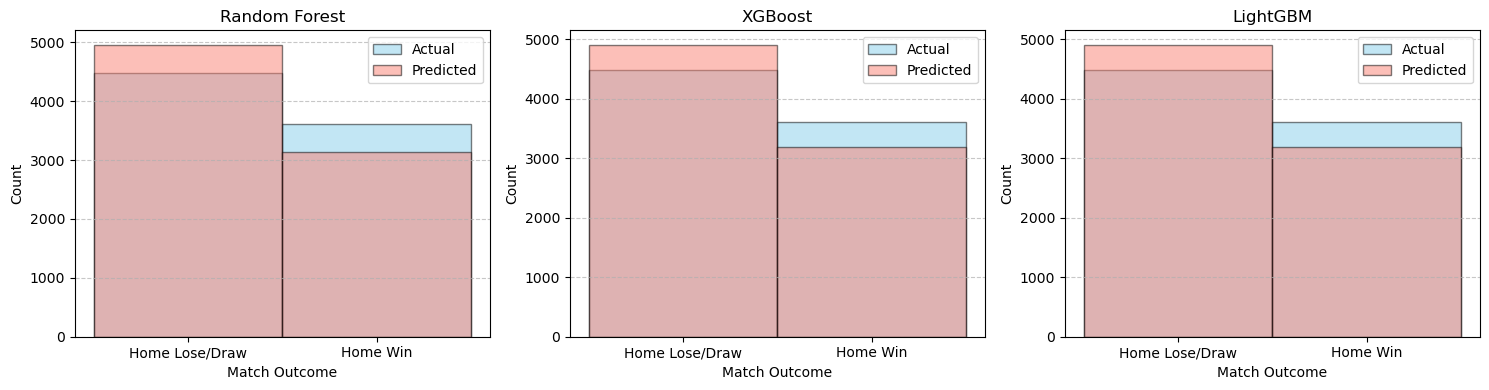

In [38]:
#------ גרף חיזוי מול אמיתי ------
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))  # רוחב גדול לשלושה גרפים בשורה

for i, (name, model) in enumerate(trained_models.items(), 1):
    y_pred = model.predict(X_test)
    
    plt.subplot(1, 3, i)  # 1 שורה, 3 עמודות, גרף i
    plt.hist(y_test, bins=[-0.5, 0.5, 1.5], alpha=0.5, label='Actual', color='skyblue', edgecolor='black')
    plt.hist(y_pred, bins=[-0.5, 0.5, 1.5], alpha=0.5, label='Predicted', color='salmon', edgecolor='black')
    
    plt.xticks([0, 1], ['Home Lose/Draw', 'Home Win'])
    plt.xlabel('Match Outcome')
    plt.ylabel('Count')
    plt.title(f'{name}')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()